# 06 — Final Model A versus Model B comparison

This notebook performs the first and only reserved-test evaluation. Both best classifiers receive the same sorted records from `data/splits/test.csv`. Model A receives deterministically resized originals. Model B's primary evaluation receives SRGAN outputs generated from deterministic 32×32 versions of those same records. The completed generator remains frozen in evaluation mode; no optimizer or update is used.

## 1. Local setup

Run this notebook from the local repository after notebooks 02–05 finish. It reads the local raw dataset and completed checkpoints, then saves metrics and figures under the local `reports/` directory.

In [1]:
import sys
from pathlib import Path

start_directory = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        candidate
        for candidate in (start_directory, *start_directory.parents)
        if (candidate / 'pyproject.toml').is_file()
        and (candidate / 'src' / 'applied_ai_midterm').is_dir()
    ),
    None,
)
if PROJECT_ROOT is None:
    codex_workspace = Path.home() / 'Documents' / 'Codex'
    if codex_workspace.is_dir():
        PROJECT_ROOT = next(
            (
                config_file.parent
                for config_file in codex_workspace.rglob('pyproject.toml')
                if config_file.parent.name == 'MLawson-Applied-AI-Midterm'
                and (config_file.parent / 'src' / 'applied_ai_midterm').is_dir()
            ),
            None,
        )
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        'Open this notebook from inside the MLawson-Applied-AI-Midterm repository.'
    )

sys.path.insert(0, str(PROJECT_ROOT / 'src'))
print(f'Local project root: {PROJECT_ROOT}')
print(f'Python kernel: {sys.executable}')

Local project root: <PROJECT_ROOT>
Python kernel: <PROJECT_ROOT>/.venv/bin/python


## 2. Select the device and verify every required artifact

The Model B best checkpoint records which SRGAN checkpoint produced its training images. Evaluation stops if that identifier differs from the supplied generator checkpoint.

In [2]:
from applied_ai_midterm.config import load_config
from applied_ai_midterm.evaluation import evaluate_model_comparison
from applied_ai_midterm.training import seed_everything, select_device

config = load_config(PROJECT_ROOT / 'configs' / 'config.yaml')
seed_everything(config.random_seed)
device = select_device()
RAW_DIRECTORY = PROJECT_ROOT / 'data' / 'raw'
TEST_MANIFEST = PROJECT_ROOT / 'data' / 'splits' / 'test.csv'
MODEL_A_BEST = (
    PROJECT_ROOT
    / 'artifacts'
    / 'checkpoints'
    / 'model_a'
    / 'classifier_a_best.pt'
)
MODEL_B_BEST = (
    PROJECT_ROOT
    / 'artifacts'
    / 'checkpoints'
    / 'model_b'
    / 'classifier_b_best.pt'
)
GENERATOR_CHECKPOINT = (
    PROJECT_ROOT
    / 'artifacts'
    / 'checkpoints'
    / 'srgan'
    / 'srgan_epoch_0150.pt'
)
REPORT_ROOT = PROJECT_ROOT / 'reports'
METRICS_DIRECTORY = REPORT_ROOT / 'metrics'
FIGURES_DIRECTORY = REPORT_ROOT / 'figures'

required_paths = {
    RAW_DIRECTORY: 'Upload the raw dataset as described in notebook 01.',
    TEST_MANIFEST: 'Run notebook 01 first.',
    MODEL_A_BEST: 'Run notebook 02 to completion.',
    MODEL_B_BEST: 'Run notebook 05 to completion.',
    GENERATOR_CHECKPOINT: 'Run notebook 03 through epoch 150.',
}
for required_path, instruction in required_paths.items():
    if not required_path.exists():
        raise FileNotFoundError(
            f'Required evaluation input missing: {required_path}. {instruction}'
        )
print(f'Selected device: {device}')
print(f'Reports: {REPORT_ROOT}')

Selected device: mps
Reports: <PROJECT_ROOT>/reports


## 3. Run the aligned reserved-test evaluation

This call saves JSON and CSV metrics, per-record predictions, confusion matrices, and ROC curves. It also reports Model B on directly resized originals as a clearly labeled secondary analysis. No result is hard-coded in this notebook.

In [3]:
artifacts = evaluate_model_comparison(
    test_manifest_path=TEST_MANIFEST,
    raw_directory=RAW_DIRECTORY,
    classifier_a_checkpoint=MODEL_A_BEST,
    classifier_b_checkpoint=MODEL_B_BEST,
    generator_checkpoint=GENERATOR_CHECKPOINT,
    metrics_directory=METRICS_DIRECTORY,
    figures_directory=FIGURES_DIRECTORY,
    batch_size=config.classifier_batch_size,
    num_workers=config.num_workers,
    device=device,
    include_model_b_originals=True,
)
print(f'Metrics JSON: {artifacts.metrics_json}')
print(f'Comparison CSV: {artifacts.comparison_csv}')
print(f'Predictions CSV: {artifacts.predictions_csv}')

Metrics JSON: <PROJECT_ROOT>/reports/metrics/model_comparison.json
Comparison CSV: <PROJECT_ROOT>/reports/metrics/model_comparison.csv
Predictions CSV: <PROJECT_ROOT>/reports/metrics/test_predictions.csv


## 4. Side-by-side classification and image-quality results

In [4]:
from IPython.display import display

display(artifacts.comparison_table)
quality_table = {
    'SRGAN test PSNR (dB)': artifacts.psnr,
    'SRGAN test SSIM': artifacts.ssim,
}
quality_table

,evaluation,accuracy,precision,recall,f1,roc_auc
0,model_a_original,0.975264,0.966387,0.984747,0.975480,0.996794
1,model_b_srgan,0.954807,0.949722,0.960396,0.955029,0.991399
2,model_b_original_secondary,0.920444,0.916049,0.925609,0.920804,0.977327


{'SRGAN test PSNR (dB)': 27.257213037845077,
 'SRGAN test SSIM': 0.8779221779443568}

## 5. Classification reports

In [5]:
import pandas as pd

for evaluation_name, result in artifacts.evaluations.items():
    print(evaluation_name.replace('_', ' ').title())
    display(pd.DataFrame(result.classification_report).transpose())

Model A Original


,precision,recall,f1-score,support
cats,0.984473,0.965794,0.975044,3742.000000
dogs,0.966387,0.984747,0.975480,3737.000000
accuracy,0.975264,0.975264,0.975264,0.975264
macro avg,0.975430,0.975270,0.975262,7479.000000
weighted avg,0.975436,0.975264,0.975262,7479.000000


Model B Srgan


,precision,recall,f1-score,support
cats,0.960000,0.949225,0.954582,3742.000000
dogs,0.949722,0.960396,0.955029,3737.000000
accuracy,0.954807,0.954807,0.954807,0.954807
macro avg,0.954861,0.954811,0.954806,7479.000000
weighted avg,0.954865,0.954807,0.954806,7479.000000


Model B Original Secondary


,precision,recall,f1-score,support
cats,0.924926,0.915286,0.920081,3742.000000
dogs,0.916049,0.925609,0.920804,3737.000000
accuracy,0.920444,0.920444,0.920444,0.920444
macro avg,0.920487,0.920447,0.920442,7479.000000
weighted avg,0.920490,0.920444,0.920442,7479.000000


## 6. Confusion matrices and ROC curves

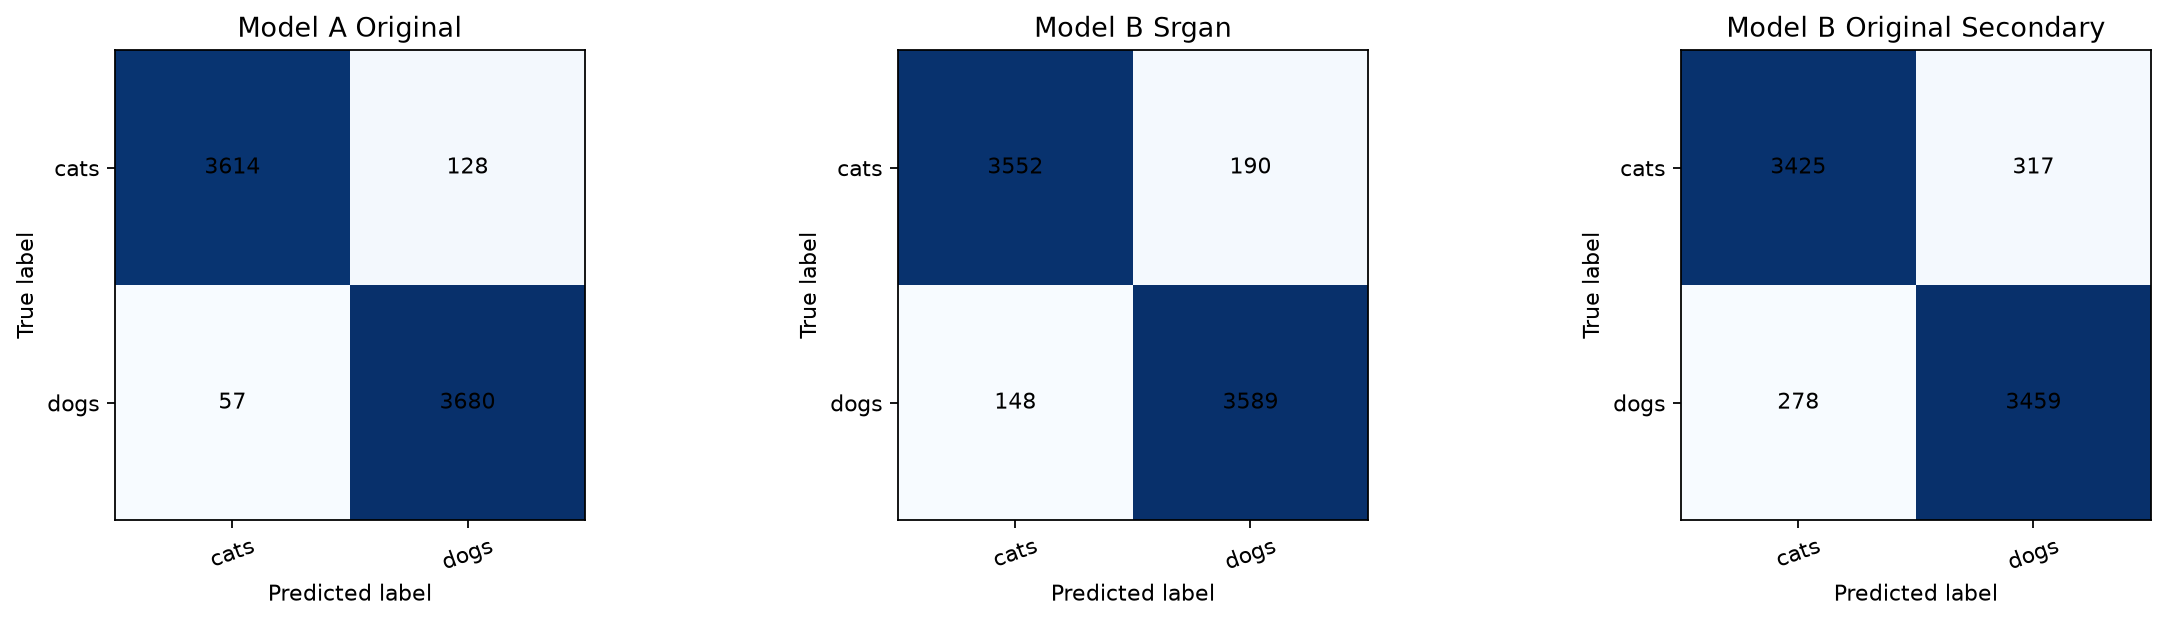

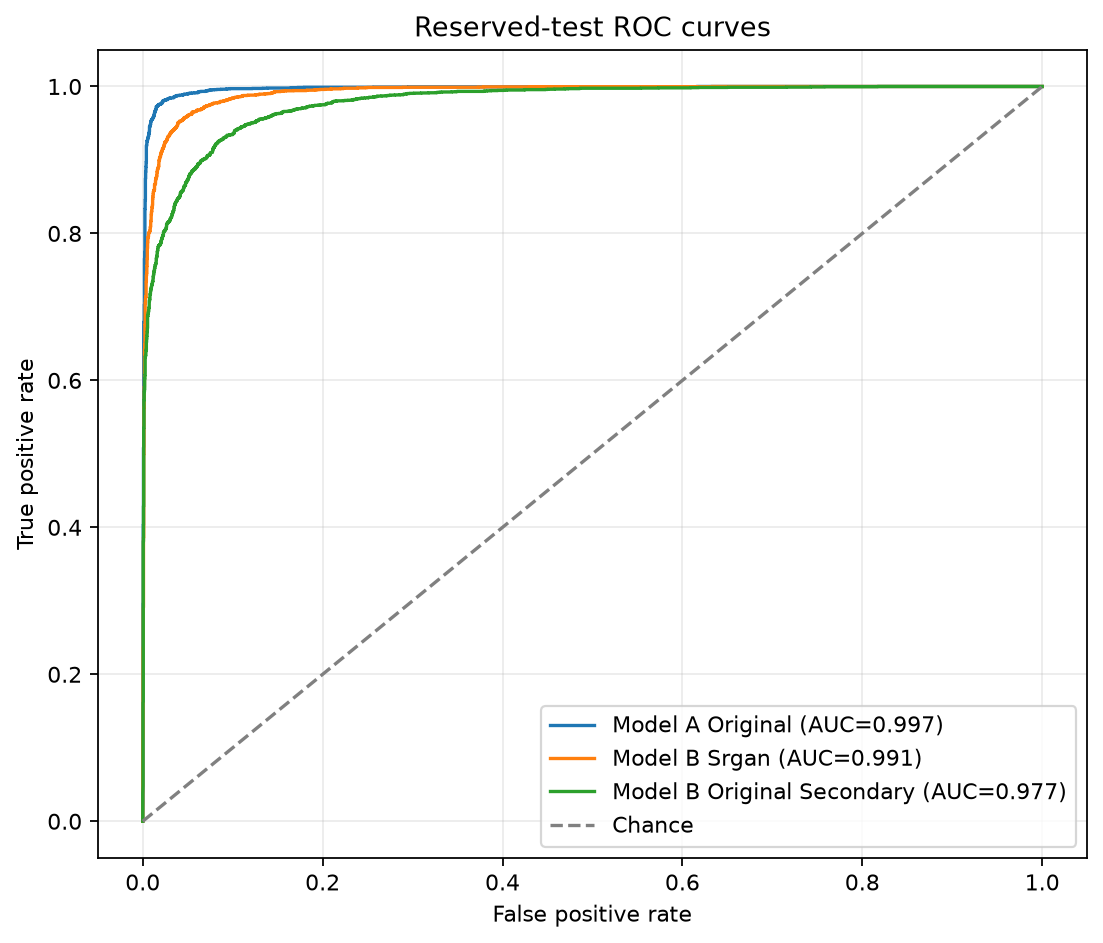

In [6]:
from IPython.display import Image as DisplayImage

display(DisplayImage(filename=str(artifacts.confusion_figure)))
display(DisplayImage(filename=str(artifacts.roc_figure)))